### EDA

#### Initial exploration and data quality assessment

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

CLEANED_CSV_FILEPATH = '../data/cleaned_car_listings.csv'
FINAL_DATASET_FILEPATH = '../data/dataset.csv'

In [2]:
df = pd.read_csv(CLEANED_CSV_FILEPATH)

In the data collection process, the listings that did not contain values for the selected features were ignored, so we don't have any missing values in the dataset.

In [3]:
# display missing values count
df.isnull().sum()

make                  0
model                 0
year                  0
body_type             0
mileage               0
door_count            0
nr_seats              0
color                 0
fuel_type             0
engine_capacity       0
engine_power          0
gearbox               0
transmission          0
pollution_standard    0
price                 0
dtype: int64

#### Helper functions

In [4]:
def create_boxplot(df, columns, title=None, num_rows=2, figsize=(8, 6)):
    num_plots = len(columns)

    fig, axes = plt.subplots(num_rows, (num_plots + 1) // num_rows, figsize=figsize)
    axes = axes.flatten()

    for ax, col in zip(axes, columns):
        ax.boxplot(df[col], vert=True, patch_artist=True)
        ax.set_xticks([])
        ax.set_xlabel(col)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
        ax.set_xlabel(ax.get_xlabel(), fontsize=14)
        ax.set_ylabel(ax.get_ylabel(), fontsize=14)

    # hide any unused subplots
    for ax in axes[num_plots:]:
        ax.axis('off')

    if title:
        fig.suptitle(title, fontsize=16)
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
    
    plt.show()

def compute_boxplot_stats(df, columns):
    stats = {}
    for col in columns:
        desc = df[col].describe()
        Q1 = desc['25%']
        Q3 = desc['75%']
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        lower_whisker = df[df[col] >= lower_bound][col].min()
        upper_whisker = df[df[col] <= upper_bound][col].max()
        stats[col] = {
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'lower_whisker': lower_whisker,
            'upper_whisker': upper_whisker,
            'min': desc['min'],
            'max': desc['max'],
            'mean': desc['mean'],
        }
    return pd.DataFrame(stats)

def plot_categorical_feature(df, feature, feature_name=None, figsize=(8, 5), format_func=None):
    counts = df[feature].value_counts()
    plt.figure(figsize=figsize)
    counts.plot(kind='bar', color='purple')
    plt.title(f'Distribution of {feature_name if feature_name else feature}')

    # add an additional parameter which is a function to format the x-axis labels if needed
    if format_func:
        plt.xticks(ticks=np.arange(len(counts.index)), labels=[format_func(label) for label in counts.index])

    plt.ylabel('Count')
    plt.xticks()
    plt.show()

def plot_numerical_feature_distribution(df, feature, feature_name, bin_width=10, min_value=None, figsize=(8, 5), format_func=None):
    plt.figure(figsize=figsize)
    bins = np.arange(min_value if min_value is not None else df[feature].min(), df[feature].max() + bin_width, bin_width)
    plt.hist(df[feature], bins=bins, color='purple')
    plt.title(f'Distribution of {feature_name if feature_name else feature}')
    plt.xlabel(feature)

    # add an additional parameter which is a function to format the x-axis labels if needed
    if format_func:
        plt.xticks(ticks=bins, labels=[format_func(label) for label in bins])

    plt.ylabel('Frequency')
    plt.show()

def plot_contingency_table_heatmap(df, feature1, feature2):
    contingency_table = pd.crosstab(df[feature1], df[feature2], normalize='index')
    plt.figure(figsize=(9, 6))
    ax = sns.heatmap(
        contingency_table, 
        annot=True,
        fmt='.0%',
        cmap='Blues',
        cbar=True,
        linewidths=.5,
        annot_kws={"size": 15},
    )
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

def plot_variance(df, feature):
    ax = sns.countplot(x=feature, data=df, color='blue')

    total = len(df)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        if p.get_height() > 0:
            ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha = 'center', va = 'bottom', fontsize=11, color='black', weight='bold')

    ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)

def plot_boxplot_overlap(df, feature, target_feature, top_value):
    sns.boxplot(x=feature, y=target_feature, data=df, palette='Blues')

    # calculate the median price of the dominant group
    median_top_value = df[df[feature] == top_value][target_feature].median()

    # add a red dashed line across the chart at that median price
    plt.axhline(y=median_top_value, color='red', linestyle='--', linewidth=2, 
                label=f'Median {target_feature} ({feature} = {top_value}): €{median_top_value:,.0f}')

#### Drop redundant features

After analysing the contingency tables, I chose to drop the **door_count** and **nr_seats** columns, as most likely they are redundant information.

For example, 98.1% of the SUVs have 5 doors, or 100% of the cars with 8 seats have the body_type Monovolum.

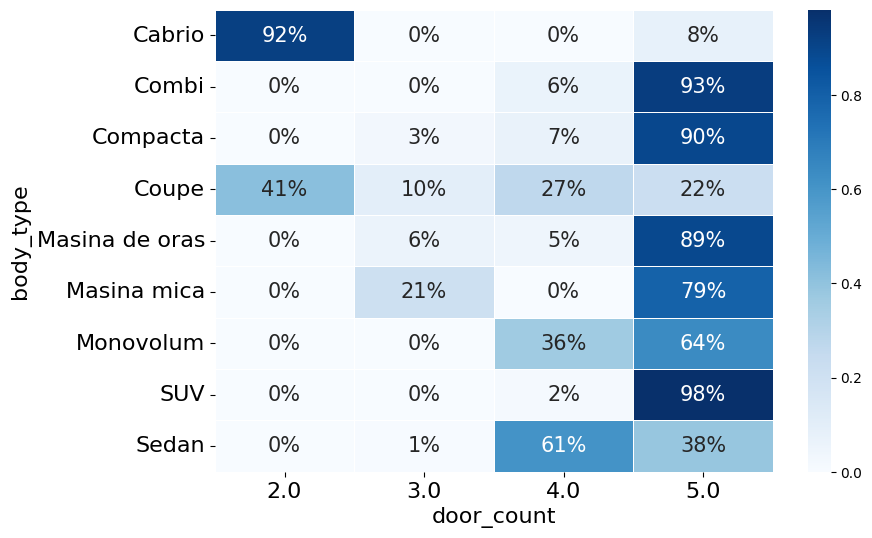

In [5]:
plot_contingency_table_heatmap(df, 'body_type', 'door_count')

/tmp/ipykernel_543193/2289986309.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
/tmp/ipykernel_543193/2289986309.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)


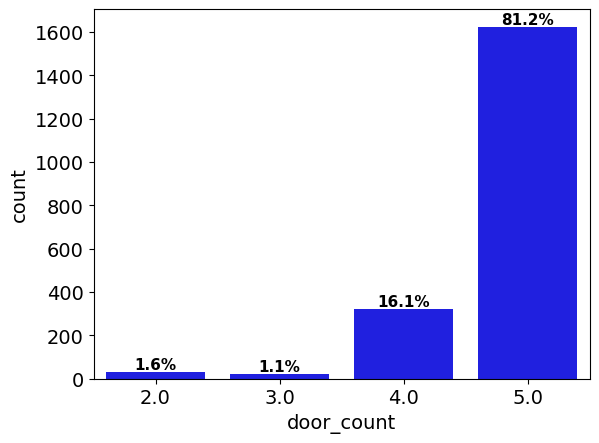

In [6]:
plot_variance(df, "door_count")

/tmp/ipykernel_543193/2289986309.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feature, y=target_feature, data=df, palette='Blues')


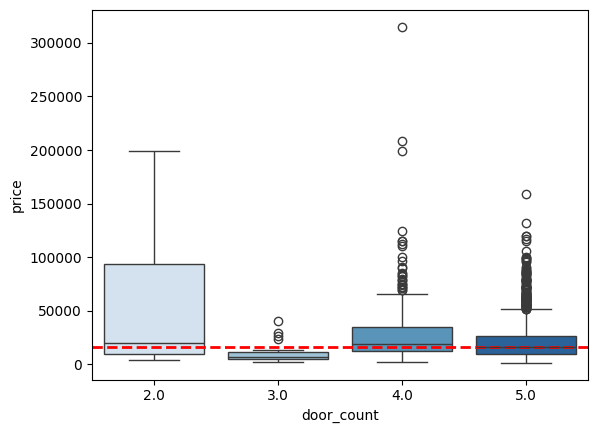

In [7]:
plot_boxplot_overlap(df, 'door_count', 'price', 5)

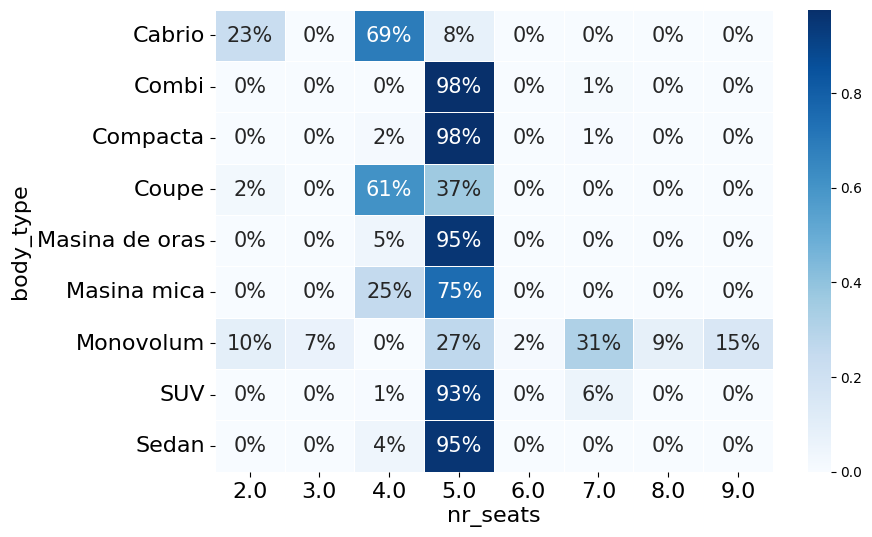

In [8]:
plot_contingency_table_heatmap(df, 'body_type', 'nr_seats')

/tmp/ipykernel_543193/2289986309.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
/tmp/ipykernel_543193/2289986309.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)


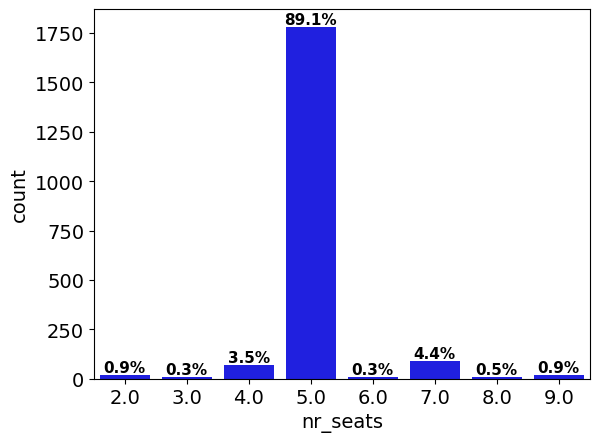

In [9]:
plot_variance(df, "nr_seats")

/tmp/ipykernel_543193/2289986309.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feature, y=target_feature, data=df, palette='Blues')


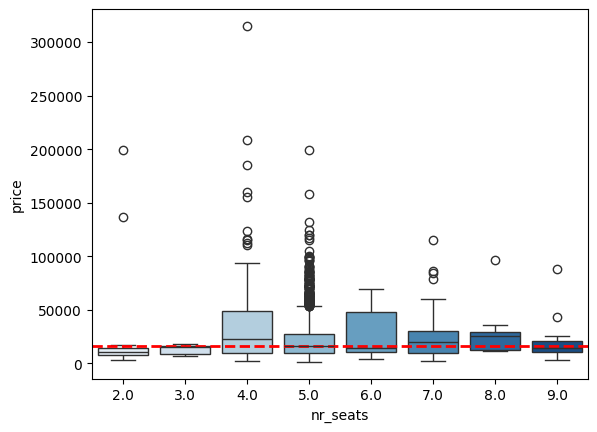

In [10]:
plot_boxplot_overlap(df, 'nr_seats', 'price', 5)

In [ ]:
# drop the 'door_count' and 'nr_seats' columns
df = df.drop(columns=['door_count', 'nr_seats']).reset_index(drop=True)
df

,make,model,year,body_type,mileage,color,fuel_type,engine_capacity,engine_power,gearbox,transmission,pollution_standard,price
0,BMW,X3,2015.0,SUV,194382.0,Maro,Diesel,1995.0,190.0,Automata,4x4 (automat),Euro 6,15990.0
1,Volvo,XC 60,2015.0,SUV,122822.0,Albastru,Diesel,2400.0,181.0,Automata,4x4 (automat),Euro 5,14000.0
2,Mercedes-Benz,B,2005.0,Monovolum,249000.0,Albastru,Diesel,1991.0,140.0,Manuala,Fata,Euro 4,3000.0
3,Peugeot,508,2012.0,Sedan,212000.0,Negru,Hibrid,1997.0,163.0,Automata,4x4 (automat),Euro 6,7400.0
4,Hyundai,Tucson,2021.0,SUV,44000.0,Gri,Hibrid Plug-In,1598.0,265.0,Automata,4x4 (automat),Euro 6,26607.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,BMW,Seria 3,2014.0,Combi,267000.0,Gri,Diesel,1995.0,143.0,Manuala,Spate,Euro 5,8498.0
1996,Peugeot,5008,2019.0,SUV,229000.0,Alte culori,Diesel,1499.0,130.0,Automata,Fata,Euro 6,14700.0
1997,Mercedes-Benz,X,2018.0,SUV,136458.0,Negru,Diesel,2298.0,190.0,Automata,4x4 (automat),Euro 6,24400.0
1998,Peugeot,308,2018.0,Combi,137000.0,Gri,Benzina,1199.0,130.0,Manuala,Fata,Euro 6,8400.0


After the initial data cleaning step, the data types are consistent, and we can identify the numerical and categorical features.

In [12]:
numerical_features = [
    "year",
    "mileage",
    "engine_capacity",
    "engine_power",
    "price"
]

categorical_features = [
    "make",
    "model",
    "body_type",
    "color",
    "fuel_type",
    "gearbox",
    "transmission",
    "pollution_standard"
]

df.dtypes

make                   object
model                  object
year                  float64
body_type              object
mileage               float64
color                  object
fuel_type              object
engine_capacity       float64
engine_power          float64
gearbox                object
transmission           object
pollution_standard     object
price                 float64
dtype: object

#### Univariate analysis

Analyze each feature independently to understand distributions and quality of data, and make informed decisions to filter out data in order to remove listings that may contain inaccurate data, or are outliers which may impact the training process.

Steps for each feature:
- Explore data before filtering
- Make filtering decisions, apply techniques
- Analyze data after filtering

##### Numerical features

In [13]:
df[numerical_features].describe()

,year,mileage,engine_capacity,engine_power,price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2017.734500,153495.731000,1925.024500,183.634000,22809.222865
std,4.434167,80031.756175,615.794162,91.492111,22287.462544
min,1971.000000,1.000000,875.000000,60.000000,1390.000000
25%,2015.000000,94994.500000,1499.000000,121.750000,9900.000000
50%,2019.000000,154088.500000,1968.000000,150.000000,16450.000000
75%,2021.000000,209000.000000,1998.000000,204.000000,27950.000000
max,2025.000000,530575.000000,6750.000000,802.000000,315000.000000


Use boxplots for a visual representation of the data dispersion. (Do not normalize data, I want to reveal domain-relevant outliers)

/tmp/ipykernel_543193/2289986309.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
/tmp/ipykernel_543193/2289986309.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
/tmp/ipykernel_543193/2289986309.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
/tmp/ipykernel_543193/2289986309.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
/tmp/ipykernel_543193/2289986309.py:12: UserWarning: set_ticklabels() should only be used with a fixed n

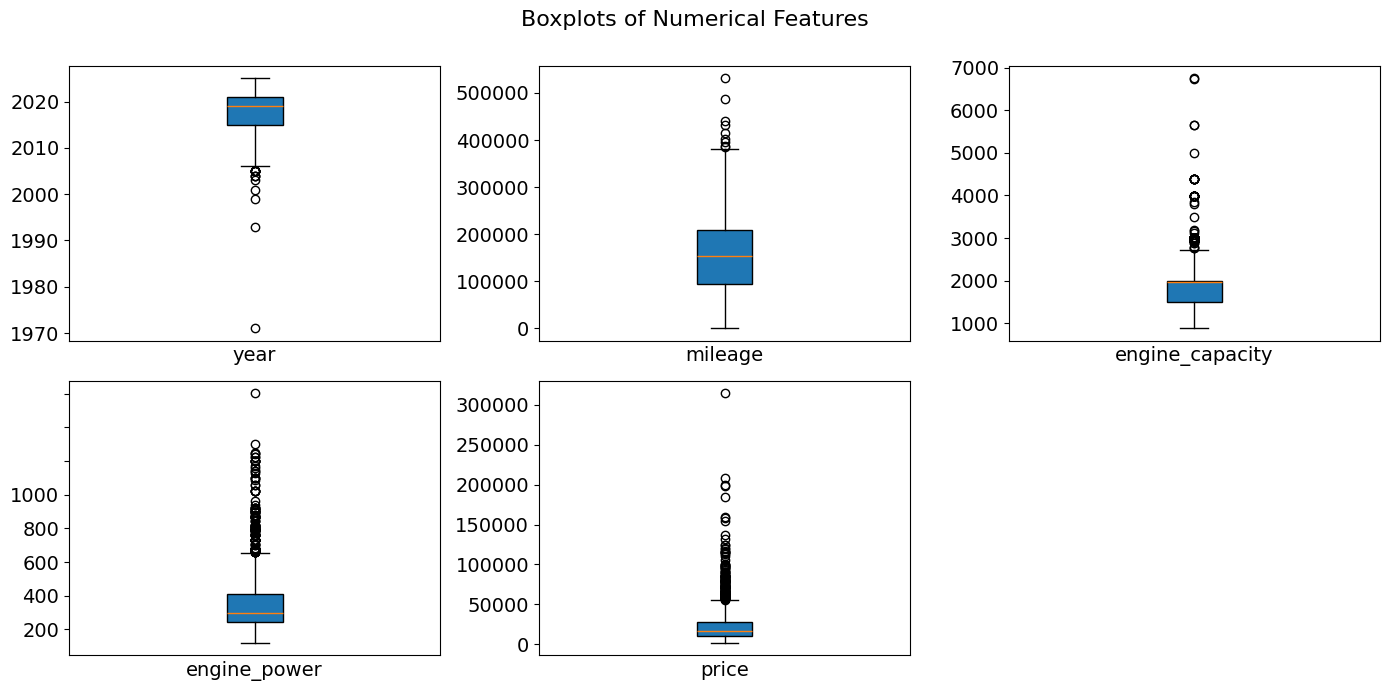

,year,mileage,engine_capacity,engine_power,price
Q1,2015.0000,94994.500,1499.0000,121.750,9900.000000
Q3,2021.0000,209000.000,1998.0000,204.000,27950.000000
IQR,6.0000,114005.500,499.0000,82.250,18050.000000
lower_whisker,2006.0000,1.000,875.0000,60.000,1390.000000
upper_whisker,2025.0000,380000.000,2720.0000,327.000,55000.010000
min,1971.0000,1.000,875.0000,60.000,1390.000000
max,2025.0000,530575.000,6750.0000,802.000,315000.000000
mean,2017.7345,153495.731,1925.0245,183.634,22809.222865


In [14]:
create_boxplot(df, numerical_features, title="Boxplots of Numerical Features", num_rows=2, figsize=(14, 7))
compute_boxplot_stats(df, numerical_features)

Interpretation:
- **year**
  - datasets contains mostly cars manufactured after the year 2006
  - filtering decision: remove cars before 2006
  
- **mileage**
  - most cars have between 90,000 km -200,000 km
  - we can see that the minimum value is 1km!!! this is suspicious, and we need to filter out entries with mileage below a fixed threshold, as it's possible they might either contain errors, or they are not representative to the **used** cars category
  - not a universally agreed upon mileage threshold for a car to be considered new/used, but from various online sources, it's typically acceptable and expected for cars to have a few hundred kms on board, due to factory testing, transport, dealership testing, etc., even more for new cars that are used as demos
  - filtering decisions:
    - remove outliers above 400,000 km
    - remove entries with mileage < 1,000km, as they are not meaningfully categorized as **used** cars (in our scope)

- **engine capacity**
  - most cars have 1500-2000 cm3 engines
  - clear outliers: high-performance vehicles with over 5000cm3
  - not necessarily data errors, but higher end cars
  - filtering decision:
    - for the scope of this project, I will not filter out these entries

- **engine_power**
  - most cars have an engine power between 120-200 HP
  - not necessarily data errors, but maybe higher end cars
  - filtering decision:
    - remove luxury cars with over 400HP
  
- **price**
  - most cars are priced between 10,000 and 28,000 EUR
  - filtering decision:
    - remove luxury cars with a price exceeding 100,000 EUR

In [15]:
# remove entries with manufacturing year before 2006
df = df[df['year'] >= 2006]

# remove entries with mileage over 400,000 km and under 1,000 km
df = df[(df['mileage'] <= 400000) & (df['mileage'] >= 1000)]

# remove entries with engine power over 400 HP
df = df[df['engine_power'] <= 400]

# remove entries with price over 100,000 EUR
df = df[df['price'] <= 100000]

df

,make,model,year,body_type,mileage,color,fuel_type,engine_capacity,engine_power,gearbox,transmission,pollution_standard,price
0,BMW,X3,2015.0,SUV,194382.0,Maro,Diesel,1995.0,190.0,Automata,4x4 (automat),Euro 6,15990.00
1,Volvo,XC 60,2015.0,SUV,122822.0,Albastru,Diesel,2400.0,181.0,Automata,4x4 (automat),Euro 5,14000.00
3,Peugeot,508,2012.0,Sedan,212000.0,Negru,Hibrid,1997.0,163.0,Automata,4x4 (automat),Euro 6,7400.00
4,Hyundai,Tucson,2021.0,SUV,44000.0,Gri,Hibrid Plug-In,1598.0,265.0,Automata,4x4 (automat),Euro 6,26607.90
5,Audi,A6,2022.0,Sedan,140558.0,Alb,Hibrid Plug-In,1984.0,367.0,Automata,4x4 (automat),Euro 6,41899.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,BMW,Seria 3,2014.0,Combi,267000.0,Gri,Diesel,1995.0,143.0,Manuala,Spate,Euro 5,8498.00
1996,Peugeot,5008,2019.0,SUV,229000.0,Alte culori,Diesel,1499.0,130.0,Automata,Fata,Euro 6,14700.00
1997,Mercedes-Benz,X,2018.0,SUV,136458.0,Negru,Diesel,2298.0,190.0,Automata,4x4 (automat),Euro 6,24400.00
1998,Peugeot,308,2018.0,Combi,137000.0,Gri,Benzina,1199.0,130.0,Manuala,Fata,Euro 6,8400.00


/tmp/ipykernel_543193/2289986309.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
/tmp/ipykernel_543193/2289986309.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
/tmp/ipykernel_543193/2289986309.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
/tmp/ipykernel_543193/2289986309.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
/tmp/ipykernel_543193/2289986309.py:12: UserWarning: set_ticklabels() should only be used with a fixed n

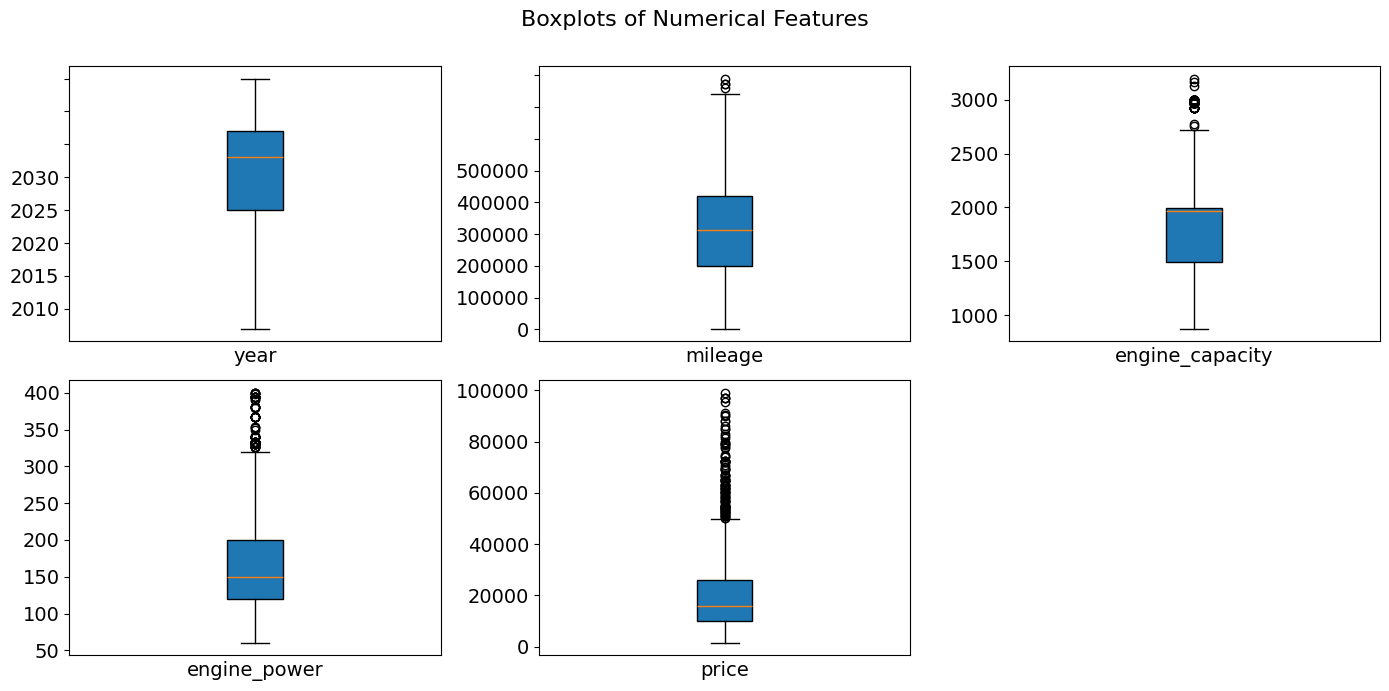

,year,mileage,engine_capacity,engine_power,price
Q1,2015.000000,99200.000000,1498.000000,120.000000,9890.540000
Q3,2021.000000,209230.000000,1996.000000,200.000000,26000.000000
IQR,6.000000,110030.000000,498.000000,80.000000,16109.460000
lower_whisker,2006.000000,1000.000000,875.000000,60.000000,1500.000000
upper_whisker,2025.000000,370000.000000,2720.000000,320.000000,50000.000000
min,2006.000000,1000.000000,875.000000,60.000000,1500.000000
max,2025.000000,395000.000000,3198.000000,400.000000,99000.000000
mean,2017.732699,155202.957211,1865.040676,172.443212,20299.769704


In [16]:
create_boxplot(df, numerical_features, title="Boxplots of Numerical Features", num_rows=2, figsize=(14, 7))
compute_boxplot_stats(df, numerical_features)

#### Categorical variables

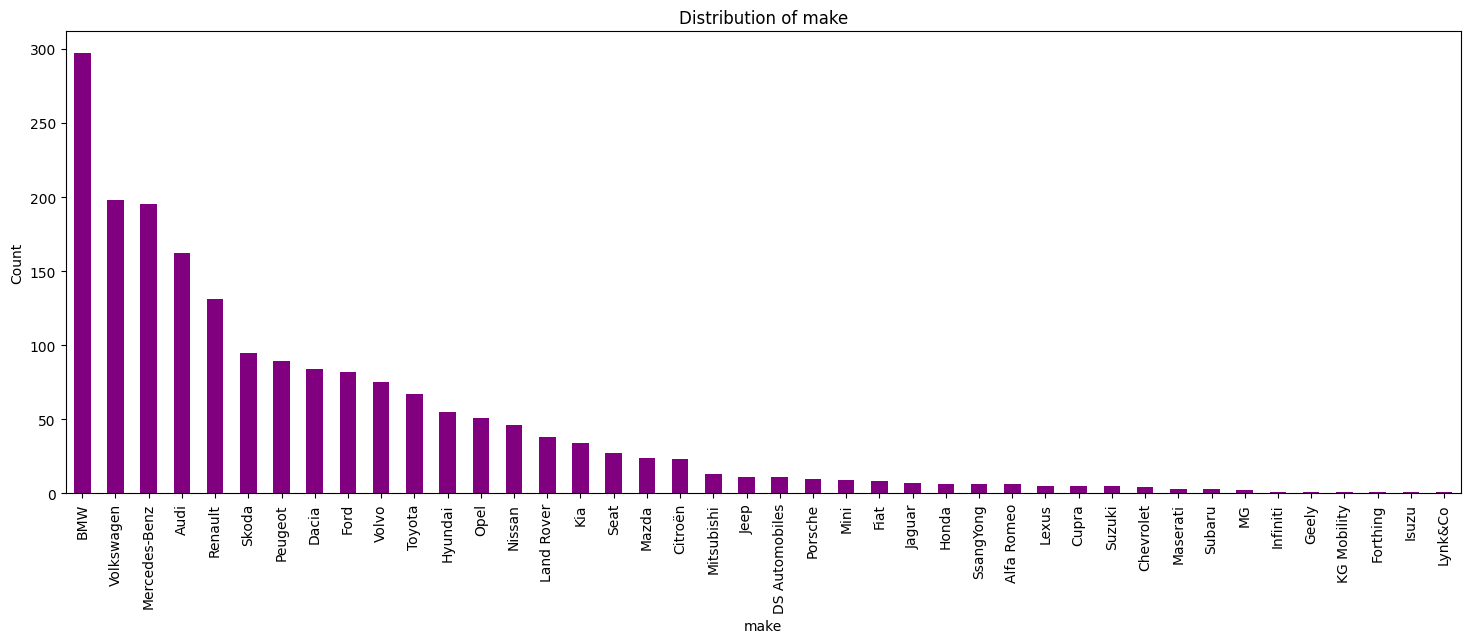

In [17]:
plot_categorical_feature(df, 'make', figsize=(18, 6))

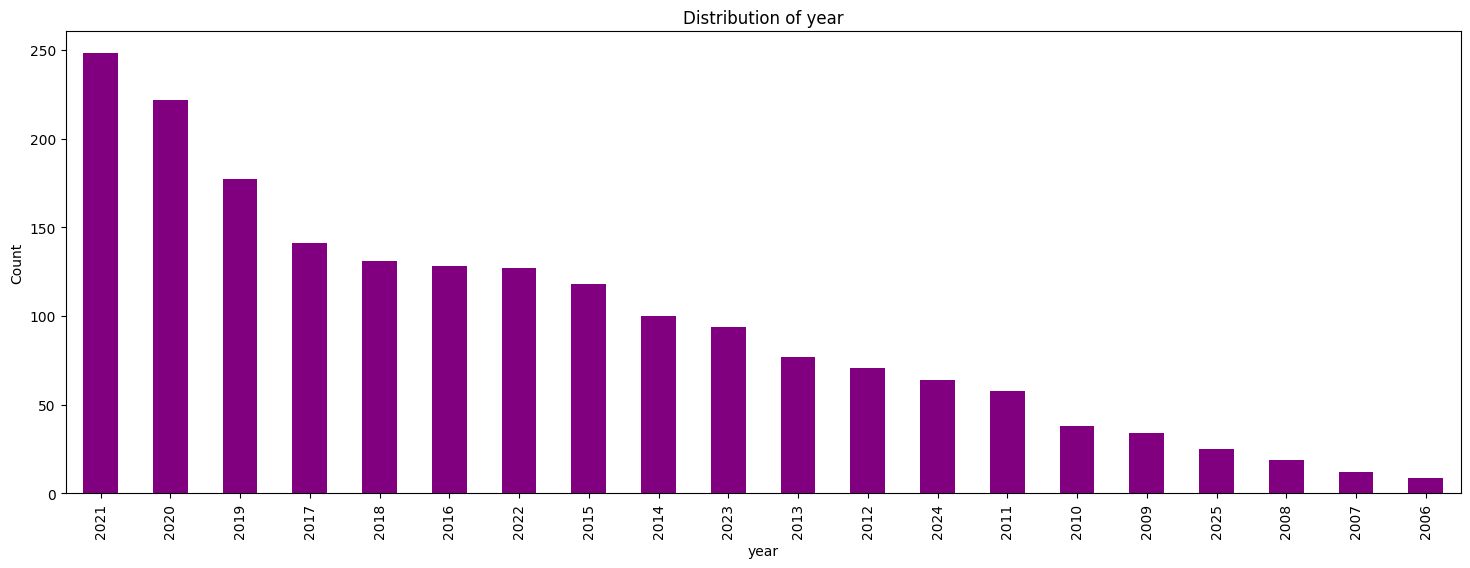

In [18]:
plot_categorical_feature(df, 'year', figsize=(18, 6), format_func=int)

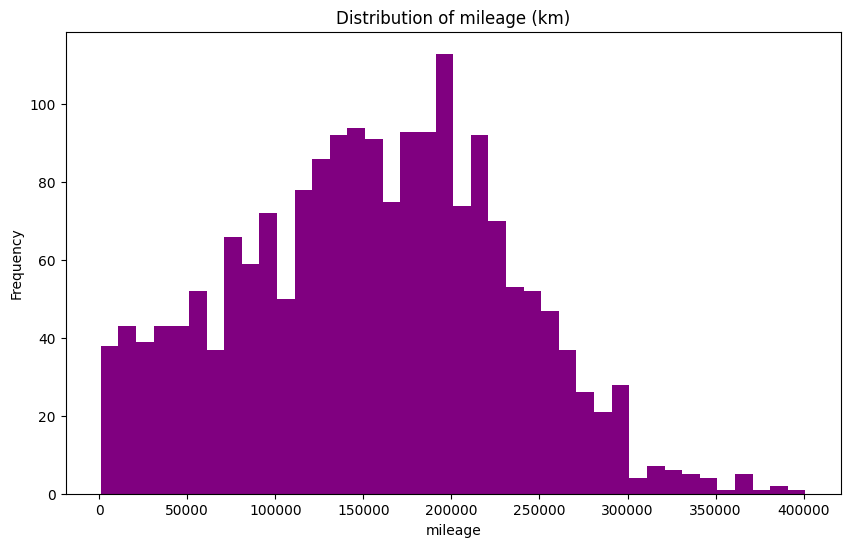

In [19]:
plot_numerical_feature_distribution(df, 'mileage', 'mileage (km)', bin_width=10000, figsize=(10, 6))

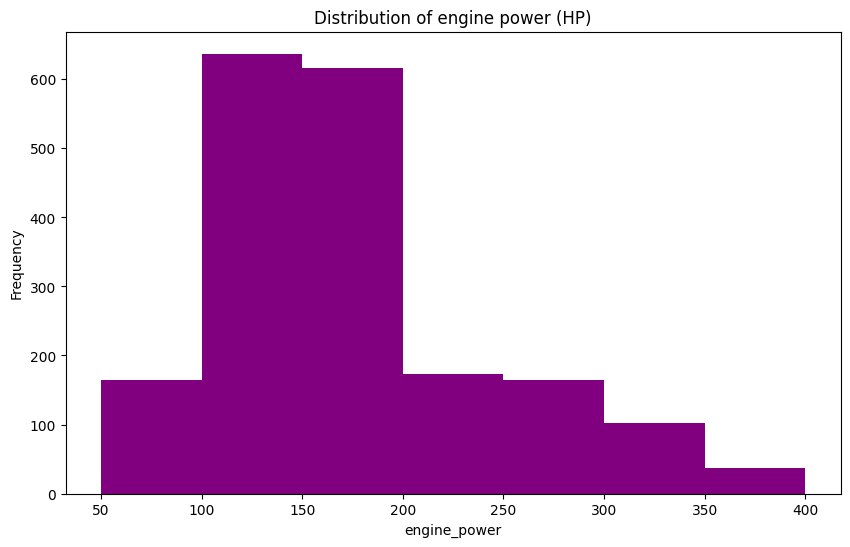

In [20]:
plot_numerical_feature_distribution(df, 'engine_power', 'engine power (HP)', bin_width=50, min_value=50, figsize=(10, 6))

In [21]:
# sorted(df['make'].unique())
# sorted(df['model'].unique())
# sorted(df['body_type'].unique())
# sorted(df['color'].unique())
# sorted(df['fuel_type'].unique())
sorted(df['gearbox'].unique())
# sorted(df['transmission'].unique())
# sorted(df['pollution_standard'].unique())

['Automata', 'Manuala']

Save the final dataset

In [ ]:
df.to_csv(FINAL_DATASET_FILEPATH)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1893 entries, 0 to 1892
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make                1893 non-null   object 
 1   model               1893 non-null   object 
 2   year                1893 non-null   float64
 3   body_type           1893 non-null   object 
 4   mileage             1893 non-null   float64
 5   color               1893 non-null   object 
 6   fuel_type           1893 non-null   object 
 7   engine_capacity     1893 non-null   float64
 8   engine_power        1893 non-null   float64
 9   gearbox             1893 non-null   object 
 10  transmission        1893 non-null   object 
 11  pollution_standard  1893 non-null   object 
 12  price               1893 non-null   float64
dtypes: float64(5), object(8)
memory usage: 192.4+ KB


In [24]:
df

,make,model,year,body_type,mileage,color,fuel_type,engine_capacity,engine_power,gearbox,transmission,pollution_standard,price
0,BMW,X3,2015.0,SUV,194382.0,Maro,Diesel,1995.0,190.0,Automata,4x4 (automat),Euro 6,15990.00
1,Volvo,XC 60,2015.0,SUV,122822.0,Albastru,Diesel,2400.0,181.0,Automata,4x4 (automat),Euro 5,14000.00
2,Peugeot,508,2012.0,Sedan,212000.0,Negru,Hibrid,1997.0,163.0,Automata,4x4 (automat),Euro 6,7400.00
3,Hyundai,Tucson,2021.0,SUV,44000.0,Gri,Hibrid Plug-In,1598.0,265.0,Automata,4x4 (automat),Euro 6,26607.90
4,Audi,A6,2022.0,Sedan,140558.0,Alb,Hibrid Plug-In,1984.0,367.0,Automata,4x4 (automat),Euro 6,41899.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1888,BMW,Seria 3,2014.0,Combi,267000.0,Gri,Diesel,1995.0,143.0,Manuala,Spate,Euro 5,8498.00
1889,Peugeot,5008,2019.0,SUV,229000.0,Alte culori,Diesel,1499.0,130.0,Automata,Fata,Euro 6,14700.00
1890,Mercedes-Benz,X,2018.0,SUV,136458.0,Negru,Diesel,2298.0,190.0,Automata,4x4 (automat),Euro 6,24400.00
1891,Peugeot,308,2018.0,Combi,137000.0,Gri,Benzina,1199.0,130.0,Manuala,Fata,Euro 6,8400.00
